In [1]:
# ------ Install dependency and import libraries needed ------
#!pip install requests numpy polars pandas matplotlib psycopg
import io
import os
import re
import requests
import math
from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
from pathlib import Path
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import urllib3
import subprocess

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# general settings for polars
pl.Config.set_tbl_cols(1000)
pl.Config.set_tbl_width_chars(1000) 

polars.config.Config

# PUE plot
This notebook contains the code to produce the PUE plot. 

In [2]:
# ----- CONSTANTS -----
time_min = datetime.fromisoformat('2026-03-19T20:03:30.024Z')
time_max = datetime.fromisoformat('2026-03-29T00:00:00+00:00')

PRJ_ROOT_DIR = Path(
    subprocess.check_output(
        ["git", "rev-parse", "--show-toplevel"],
        text=True
    ).strip()
)
DATA_DIR = Path(PRJ_ROOT_DIR, "data")
print(f"Project data directory detected: {DATA_DIR}")

Project data directory detected: /orfeo/cephfs/scratch/area/ntosato/infrastructure-level-data-collection/data


In [3]:
def read_data_from_parquet(table_name, timefilter=None, column_names=None, data_dir=DATA_DIR):
    parquet_files = sorted((data_dir / table_name).glob("*.parquet"))

    if not parquet_files:
        print(f"No parquet files found for table {table_name} in {data_dir / table_name}")
        return pl.DataFrame()

    if timefilter is not None:
        time_min, time_max = timefilter

        selected_files = []
        for file in parquet_files:
            parts = file.stem.split("_")
            file_start = datetime.fromisoformat(parts[-2]).replace(tzinfo=time_min.tzinfo)
            file_end = datetime.fromisoformat(parts[-1]).replace(tzinfo=time_min.tzinfo)

            if file_start <= time_max and file_end >= time_min:
                selected_files.append(file)

        parquet_files = selected_files

    if not parquet_files:
        print(f"No parquet files overlap requested timerange for table {table_name}")
        return pl.DataFrame()

    dfs = []
    for file in parquet_files:
        try:
            df = pl.read_parquet(file)
            if column_names:
                df = df.select(column_names)
            dfs.append(df)
        except Exception as e:
            print(f"Error reading {file}: {e}")

    if not dfs:
        print(f"No valid parquet files found for table {table_name} in {data_dir / table_name}")
        return pl.DataFrame()

    df = pl.concat(dfs, how="vertical")

    if timefilter is not None:
        df = df.filter(pl.col("timestamp").is_between(timefilter[0], timefilter[1]))

    return df

In [4]:
ipmi_power = read_data_from_parquet("ipmi_power",timefilter=(time_min,time_max))
pdu_power = read_data_from_parquet("pdu_power",timefilter=(time_min,time_max),column_names=["timestamp","connected_device","port","value_W"])
energy_meter = read_data_from_parquet("energy_meter",timefilter=(time_min,time_max))

In [5]:
to_plot = energy_meter.filter(pl.col("description") == "Totalizzatore Attiva Basovizza Linea Orfeo 2").select(["timestamp", "value"])
potenza = energy_meter.filter(pl.col("description") == "P. attiva  Basovizza Linea Orfeo 2").select(["timestamp", "value"])
potenza_avg = potenza.group_by_dynamic(
    "timestamp", 
    every="10m", 
).agg(
    pl.col("value")
    .mean()
    .alias("value")
)

In [6]:
host_ipmi = ipmi_power["host"].unique().to_list()
host_pdu = pdu_power["connected_device"].unique().to_list()
host_ipmi = [host.split(".")[0] for host in host_ipmi]
missing = set(set(host_pdu) - set(host_ipmi))
pdu = [ 'Disk Enclosures 1', 'Disk Enclosures 2', 'Powervault ME disk+controller', 'ceph-svc01', 'ceph-svc02', 'dgx001', 'dgx002', 'epyc007', 'inband03', 'inband04', 'inband05', 'inband06', 'inband07', 'inband08', 'inband09', 'inband10', 'infiniband01', 'infiniband02', 'k01', 'k02', 'k03', 'kub01', 'kub02', 'nfs01', 'outband modulo 1', 'outband modulo 2', 'outband modulo 3', 'pfsense01', 'pfsense02', 'pve-00', 'pve-01', 'pve-02', 'pve-03(MDMC)']

In [7]:
# Ensure data is sorted by timestamp
pdu_power = pdu_power.sort("timestamp")
ipmi_power = ipmi_power.sort("timestamp")

# Step 1: Calculate the average power per device and per port in 30-minute intervals
avg_per_port = pdu_power.group_by_dynamic(
    "timestamp", 
    every="10m", 
    group_by=["connected_device", "port"]
).agg(
    pl.col("value_W").mean()
)

avg_per_host = ipmi_power.group_by_dynamic(
    "timestamp", 
    every="10m", 
    group_by=["host"]
).agg(
    pl.col("value")
    .filter((pl.col("psu_id") == "0") & (pl.col("unit") == "W")) # Adjust "unit" to your actual column name
    .mean()
    .alias("value_W")
)

avg_missing_hosts = avg_per_port.filter(pl.col("connected_device").is_in(pdu))

# Step 2: Sum those averages across all ports and hosts for each 15-minute timestamp bin
total_power_10m_pdu = avg_per_port.group_by("timestamp").agg(
    total_power_W=pl.col("value_W").sum()
).sort("timestamp")

total_power_10m_missing = avg_missing_hosts.group_by("timestamp").agg(
    total_power_W=pl.col("value_W").sum()
).sort("timestamp")

total_power_10m_ipmi = avg_per_host.group_by("timestamp").agg(
    total_power_W=pl.col("value_W").sum()
).sort("timestamp")


Text(0.5, 0, 'Timestamp')

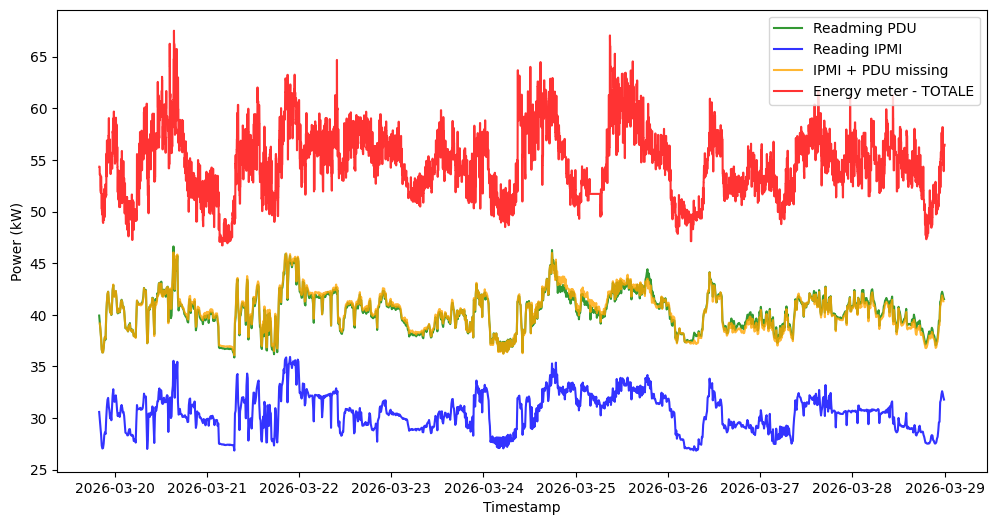

In [8]:
plt.figure(figsize=(12, 6))
plt.plot(total_power_10m_pdu["timestamp"], total_power_10m_pdu["total_power_W"]/1000, label="Readming PDU", color='green', alpha=0.8)
plt.plot(total_power_10m_ipmi["timestamp"], total_power_10m_ipmi["total_power_W"]/1000, label="Reading IPMI", color='blue', alpha=0.8)
plt.plot(total_power_10m_missing["timestamp"][1:-1], total_power_10m_missing["total_power_W"][1:-1]/1000+total_power_10m_ipmi["total_power_W"][1:-1]/1000, label="IPMI + PDU missing", color='orange', alpha=0.8)
plt.plot(potenza["timestamp"], potenza["value"]/1000, label="Energy meter - TOTALE", color='red', alpha=0.8)
plt.legend()
plt.ylabel("Power (kW)")
plt.xlabel("Timestamp")

In [9]:
try:
    import openmeteo_requests
except:
    !pip install openmeteo-requests requests-cache retry-requests
    import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": 45.64,
    "longitude": 13.85,
    "start_date": str(time_min).split(" ")[0],
    "end_date": str(time_max).split(" ")[0],
    "hourly": ["temperature_2m", "wind_speed_10m", "relative_humidity_2m"],
}

# 3. Fetch and Process
responses = openmeteo.weather_api(url, params=params)
response = responses[0]

hourly = response.Hourly()
hourly_data = {
    "date": pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    ),
    "temperature_2m": hourly.Variables(0).ValuesAsNumpy(),
    "wind_speed_10m": hourly.Variables(1).ValuesAsNumpy(),
    "relative_humidity_2m": hourly.Variables(2).ValuesAsNumpy(),
}

df = pd.DataFrame(data=hourly_data)

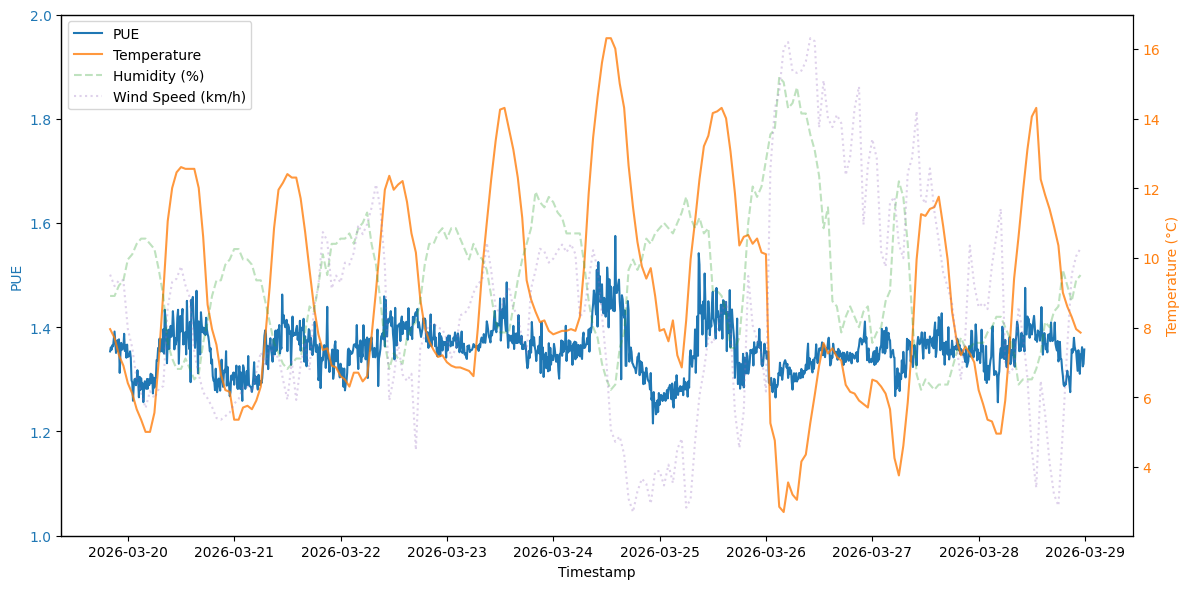

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis for PUE
color_pue = 'tab:blue'
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('PUE', color=color_pue)
ax1.plot(potenza_avg["timestamp"], potenza_avg["value"] / total_power_10m_pdu["total_power_W"], color=color_pue, label='PUE')
ax1.set_ylim(1, 2) # Limits
ax1.tick_params(axis='y', labelcolor=color_pue)

# Filter Open-Meteo data to the matching time bounds
t_min = potenza_avg["timestamp"].min()
t_max = potenza_avg["timestamp"].max()
filtered_weather = df[(df["date"] >= t_min) & (df["date"] <= t_max)]
#filtered_weather = df.filter((pl.col("date") >= t_min) & (pl.col("date") <= t_max))

# Secondary axis for Temperature
ax2 = ax1.twinx()  
color_temp = 'tab:orange'
ax2.set_ylabel('Temperature (°C)', color=color_temp)
ax2.plot(filtered_weather["date"], filtered_weather["temperature_2m"], color=color_temp, label='Temperature', alpha=0.8)
ax2.tick_params(axis='y', labelcolor=color_temp)

# Axis for Humidity (Hidden)
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60)) # Offset it if we were to show it
color_hum = 'tab:green'
ax3.plot(filtered_weather["date"], filtered_weather["relative_humidity_2m"], color=color_hum, label='Humidity (%)', alpha=0.3, linestyle='--')
ax3.set_ylim(0, 100) # Humidity runs 0 to 100
ax3.set_yticks([]) # HIDE axis
ax3.set_yticklabels([]) # HIDE labels

# Axis for Wind Speed (Hidden)
ax4 = ax1.twinx()
ax4.spines['right'].set_position(('outward', 120))
color_wind = 'tab:purple'
ax4.plot(filtered_weather["date"], filtered_weather["wind_speed_10m"], color=color_wind, label='Wind Speed (km/h)', alpha=0.3, linestyle=':')
# Wind speed usually doesn't need hard bounds, but we can let it auto-scale
ax4.set_yticks([]) # HIDE axis
ax4.set_yticklabels([]) # HIDE labels

# Combine legends from all axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
lines_3, labels_3 = ax3.get_legend_handles_labels()
lines_4, labels_4 = ax4.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2 + lines_3 + lines_4, labels_1 + labels_2 + labels_3 + labels_4, loc='upper left')


#fig.suptitle("PUE vs Weather Conditions Over Time")
fig.tight_layout()  
plt.savefig("pue_weather_plot.png")

plt.show()


In [11]:
results = (
    potenza_avg
    .join(total_power_10m_pdu, on="timestamp", how="inner")
    .with_columns(
        (pl.col("value") / pl.col("total_power_W")).alias("ratio")
    )
    .select(["timestamp", "ratio"])
)

results.write_parquet("pue_10m.parquet")

